<a href="https://www.kaggle.com/code/kalilurrahman/microsoft-stock-viz-forecast-analysis?scriptVersionId=312047694" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings('ignore')
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/microsoft-stock-details-updated-regularly/Microsoft_stock_info.csv
/kaggle/input/microsoft-stock-details-updated-regularly/Microsoft_stock_dividends.csv
/kaggle/input/microsoft-stock-details-updated-regularly/Microsoft_stock_history.csv
/kaggle/input/microsoft-stock-details-updated-regularly/Microsoft_stock_spilts.csv
/kaggle/input/microsoft-stock-details-updated-regularly/Microsoft_stock_action.csv


# [🔮🎯📊 Microsoft Stock Price Performance Analysis and Data Visualization 📊🎯🔮](#0)

<a id=1><h3 >1️⃣ Dataset Loading<br></h3></a>
<a id=2><h3 >2️⃣ Dataset Visualization Using Simple Plots<br></h3></a>
<a id=3><h3 >3️⃣ Dataset Visualization Using MPLFinance Plots<br></h3></a>
<a id=4><h3 >4️⃣ Stock Analysis of the data<br></h3></a>
<a id=5><h3 >5️⃣ Let us do a financial ratios calculation using FINTA library <br></h3></a>
<a id=6><h3 >6️⃣ Let us do a financial ratios calculation<br></h3></a>
<a id=7><h3 >7️⃣ Let us do a bit of forecasting using Facebook Prophet Regression <br></h3></a>
<a id=8><h3 >8️⃣ Let us do a Facebook Prophet library<br></h3></a>
</h1>


In [2]:

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib import style
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

# For reading stock data from yahoo
from pandas_datareader.data import DataReader

# For time stamps
from datetime import datetime
from math import sqrt

#ignore the warnings
import warnings
warnings.filterwarnings('ignore')


try:
    import mplfinance as mpf
    import mpl_finance as mplf
    from mpl_finance import candlestick_ohlc
except:
    !pip install mplfinance mpl_finance
    import mplfinance as mpf
    import mpl_finance as mplf
    from mpl_finance import candlestick_ohlc

     |████████████████████████████████| 75 kB 1.7 MB/s 


/opt/conda/lib/python3.7/site-packages/mpl_finance.py:22: DeprecationWarning: 



    Please use `mplfinance` instead (no hyphen, no underscore).

    To install: `pip install --upgrade mplfinance` 

   For more information, see: https://pypi.org/project/mplfinance/


  category=DeprecationWarning)


# [1️⃣. Dataset Loading](#1)

>

In [3]:
msft = pd.read_csv('../input/microsoft-stock-details-updated-regularly/Microsoft_stock_history.csv')
print(msft.head())

         Date  Adj Close     Close      High       Low      Open      Volume
0  1986-03-13   0.059253  0.097222  0.101563  0.088542  0.088542  1031788800
1  1986-03-14   0.061369  0.100694  0.102431  0.097222  0.097222   308160000
2  1986-03-17   0.062428  0.102431  0.103299  0.100694  0.100694   133171200
3  1986-03-18   0.060840  0.099826  0.103299  0.098958  0.102431    67766400
4  1986-03-19   0.059782  0.098090  0.100694  0.097222  0.099826    47894400


 # [2️⃣. Dataset Visualization Using Simple Plots](#2)


## Initial simple plots using 
* *Pandas Plotting for opening and closing prices*
* *Plotly OHLC (Open-High-Low-Close) Charts*
* *Statistical Moving Average (SMA) Charts*
* *Exponential Moving Average (EMA) Charts*


#### Simple Pandas plots for the price and volume of Microsoft Stock

<AxesSubplot:>

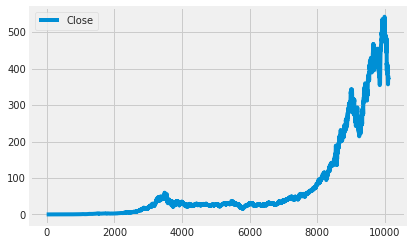

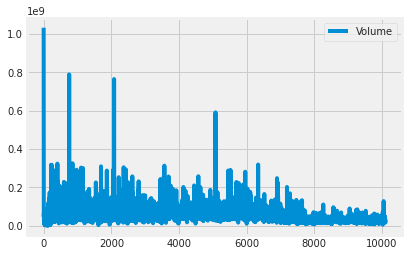

In [4]:
#Closing Price PLot
msft[["Close"]].plot()
#Volume Plot
msft[["Volume"]].plot()

#### OHLC Chart

In [5]:
#OHLC Plot using Plotly
import plotly.graph_objects as go

fig = go.Figure(data=go.Ohlc(x=msft['Date'],
        open=msft['Open'],
        high=msft['High'],
        low=msft['Low'],
        close=msft['Close']))
fig.show()

#### SMA chart plotting for 5, 20, 50, 200, 500 day moving averages

In [6]:
msft['SMA5'] = msft.Close.rolling(5).mean()
msft['SMA20'] = msft.Close.rolling(20).mean()
msft['SMA50'] = msft.Close.rolling(50).mean()
msft['SMA200'] = msft.Close.rolling(200).mean()
msft['SMA500'] = msft.Close.rolling(500).mean()

fig = go.Figure(data=[go.Ohlc(x=msft['Date'],
                              open=msft['Open'],
                              high=msft['High'],
                              low=msft['Low'],
                              close=msft['Close'], name = "OHLC"),
                      go.Scatter(x=msft.Date, y=msft.SMA5, line=dict(color='orange', width=1), name="SMA5"),
                      go.Scatter(x=msft.Date, y=msft.SMA20, line=dict(color='green', width=1), name="SMA20"),
                      go.Scatter(x=msft.Date, y=msft.SMA50, line=dict(color='blue', width=1), name="SMA50"),
                      go.Scatter(x=msft.Date, y=msft.SMA200, line=dict(color='violet', width=1), name="SMA200"),
                      go.Scatter(x=msft.Date, y=msft.SMA500, line=dict(color='purple', width=1), name="SMA500")])
fig.show()

#### EMA chart plotting for 5, 20, 50, 200, 500 day moving averages

In [7]:

msft['EMA5'] = msft.Close.ewm(span=5, adjust=False).mean()
msft['EMA20'] = msft.Close.ewm(span=20, adjust=False).mean()
msft['EMA50'] = msft.Close.ewm(span=50, adjust=False).mean()
msft['EMA200'] = msft.Close.ewm(span=200, adjust=False).mean()
msft['EMA500'] = msft.Close.ewm(span=500, adjust=False).mean()

fig = go.Figure(data=[go.Ohlc(x=msft['Date'],
                              open=msft['Open'],
                              high=msft['High'],
                              low=msft['Low'],
                              close=msft['Close'], name = "OHLC"),
                      go.Scatter(x=msft.Date, y=msft.SMA5, line=dict(color='orange', width=1), name="EMA5"),
                      go.Scatter(x=msft.Date, y=msft.SMA20, line=dict(color='green', width=1), name="EMA20"),
                      go.Scatter(x=msft.Date, y=msft.SMA50, line=dict(color='blue', width=1), name="EMA50"),
                      go.Scatter(x=msft.Date, y=msft.SMA200, line=dict(color='violet', width=1), name="EMA200"),
                      go.Scatter(x=msft.Date, y=msft.SMA500, line=dict(color='purple', width=1), name="EMA500")])
fig.show()

#### Reset the index on to the Date column

In [8]:
msft.set_index('Date')

,Adj Close,Close,High,Low,Open,Volume,SMA5,SMA20,SMA50,SMA200,SMA500,EMA5,EMA20,EMA50,EMA200,EMA500
Date,,,,,,,,,,,,,,,,
1986-03-13,0.059253,0.097222,0.101563,0.088542,0.088542,1031788800,NaN,NaN,NaN,NaN,NaN,0.097222,0.097222,0.097222,0.097222,0.097222
1986-03-14,0.061369,0.100694,0.102431,0.097222,0.097222,308160000,NaN,NaN,NaN,NaN,NaN,0.098379,0.097553,0.097358,0.097257,0.097236
1986-03-17,0.062428,0.102431,0.103299,0.100694,0.100694,133171200,NaN,NaN,NaN,NaN,NaN,0.099730,0.098017,0.097557,0.097308,0.097257
1986-03-18,0.060840,0.099826,0.103299,0.098958,0.102431,67766400,NaN,NaN,NaN,NaN,NaN,0.099762,0.098190,0.097646,0.097333,0.097267
1986-03-19,0.059782,0.098090,0.100694,0.097222,0.099826,47894400,0.099653,NaN,NaN,NaN,NaN,0.099205,0.098180,0.097663,0.097341,0.097270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-07,372.290009,372.290009,372.450012,366.559998,370.339996,21443300,371.634003,381.837000,400.168199,475.84950,443.62122,371.263379,379.799354,401.744016,446.880475,433.181682
2026-04-08,374.329987,374.329987,385.000000,371.410004,384.980011,33064800,372.465997,380.265498,398.249199,475.33415,443.51732,372.285582,379.278462,400.668956,446.158579,432.946745
2026-04-09,373.070007,373.070007,373.500000,367.049988,372.500000,30435300,373.206000,378.674998,396.099000,474.76950,443.41694,372.547057,378.687181,399.586645,445.431330,432.707716


#### Create a column on daily change percentages for the Stock

In [9]:
msft['daily_change_pct'] = msft['Close'].pct_change()*100
msft['returns'] = msft['daily_change_pct'] / msft['Close']  
msft.head()

,Date,Adj Close,Close,High,Low,Open,Volume,SMA5,SMA20,SMA50,SMA200,SMA500,EMA5,EMA20,EMA50,EMA200,EMA500,daily_change_pct,returns
0,1986-03-13,0.059253,0.097222,0.101563,0.088542,0.088542,1031788800,NaN,NaN,NaN,NaN,NaN,0.097222,0.097222,0.097222,0.097222,0.097222,NaN,NaN
1,1986-03-14,0.061369,0.100694,0.102431,0.097222,0.097222,308160000,NaN,NaN,NaN,NaN,NaN,0.098379,0.097553,0.097358,0.097257,0.097236,3.571209,35.465951
2,1986-03-17,0.062428,0.102431,0.103299,0.100694,0.100694,133171200,NaN,NaN,NaN,NaN,NaN,0.099730,0.098017,0.097557,0.097308,0.097257,1.725027,16.840867
3,1986-03-18,0.060840,0.099826,0.103299,0.098958,0.102431,67766400,NaN,NaN,NaN,NaN,NaN,0.099762,0.098190,0.097646,0.097333,0.097267,-2.543174,-25.476069
4,1986-03-19,0.059782,0.098090,0.100694,0.097222,0.099826,47894400,0.099653,NaN,NaN,NaN,NaN,0.099205,0.098180,0.097663,0.097341,0.097270,-1.739026,-17.728882


#### Create a histogram on the daily changes / percentage

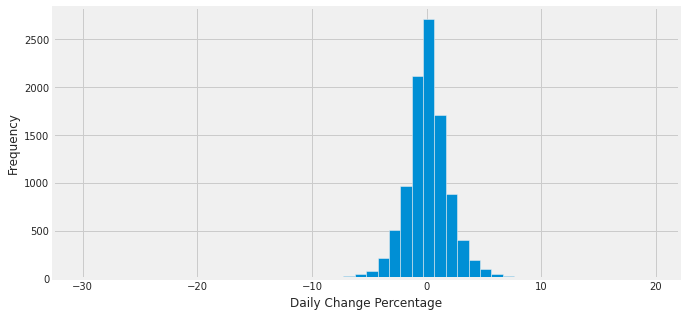

count    10097.000000
mean         0.103927
std          2.092325
min        -30.115893
25%         -0.912398
50%          0.034747
75%          1.096602
max         19.565217
Name: daily_change_pct, dtype: float64

In [10]:
msft['daily_change_pct'].fillna(0)
msft['daily_change_pct'].hist(bins = 50, figsize = (10,5)) 
plt.xlabel('Daily Change Percentage')
plt.ylabel('Frequency')
plt.show()
#print the statistics on daily change percentage
msft.daily_change_pct.describe()

#### Plot 7-day rolling averages for volume of stocks traded

<AxesSubplot:>

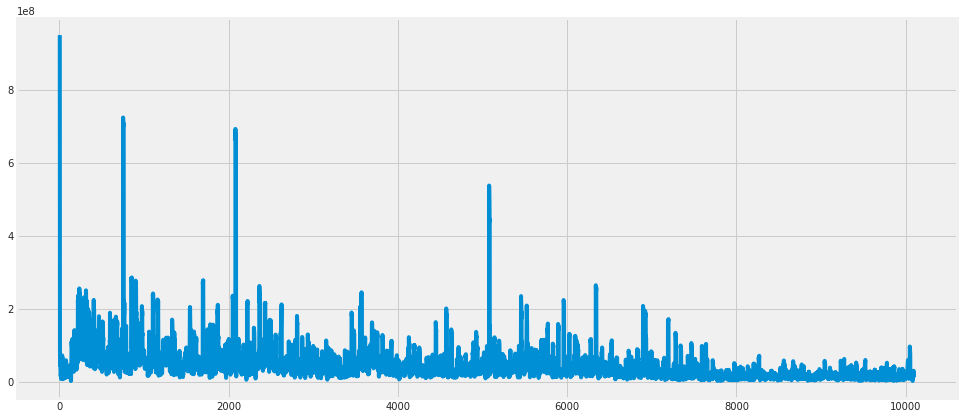

In [11]:
msft_vol = msft['Volume'].rolling(7).std()*np.sqrt(7)
msft_vol.plot(figsize = (15, 7))

#### Define a daily trend function for usage in aggregation

In [12]:
def daily_trend(x):
    if x > -0.5 and x <= 0.5:
        return 'No change'
    elif x > 0.5 and x <= 2:
        return 'Upto 2% Increase'
    elif x > -2 and x <= -0.5:
        return 'Upto 2% Decrease'
    elif x > 2 and x <= 5:
        return '2-5% Increase'
    elif x > -5 and x <= -2:
        return '2-5% Decrease'
    elif x > 5 and x <= 10:
        return '5-10% Increase'
    elif x > -10 and x <= -5:
        return '5-10% Decrease'
    elif x > 10:
        return '>10% Increase'
    elif x <= -10:
        return '>10% Decrease'

#### SMA chart plotting for 5, 20, 50, 200, 500 day moving averages

In [13]:
msft['Trend']= np.zeros(msft['daily_change_pct'].count()+1)
msft['Trend']= msft['daily_change_pct'].apply(lambda x:daily_trend(x))
msft['Trend'].replace('None','No change')
msft.head()

,Date,Adj Close,Close,High,Low,Open,Volume,SMA5,SMA20,SMA50,SMA200,SMA500,EMA5,EMA20,EMA50,EMA200,EMA500,daily_change_pct,returns,Trend
0,1986-03-13,0.059253,0.097222,0.101563,0.088542,0.088542,1031788800,NaN,NaN,NaN,NaN,NaN,0.097222,0.097222,0.097222,0.097222,0.097222,NaN,NaN,None
1,1986-03-14,0.061369,0.100694,0.102431,0.097222,0.097222,308160000,NaN,NaN,NaN,NaN,NaN,0.098379,0.097553,0.097358,0.097257,0.097236,3.571209,35.465951,2-5% Increase
2,1986-03-17,0.062428,0.102431,0.103299,0.100694,0.100694,133171200,NaN,NaN,NaN,NaN,NaN,0.099730,0.098017,0.097557,0.097308,0.097257,1.725027,16.840867,Upto 2% Increase
3,1986-03-18,0.060840,0.099826,0.103299,0.098958,0.102431,67766400,NaN,NaN,NaN,NaN,NaN,0.099762,0.098190,0.097646,0.097333,0.097267,-2.543174,-25.476069,2-5% Decrease
4,1986-03-19,0.059782,0.098090,0.100694,0.097222,0.099826,47894400,0.099653,NaN,NaN,NaN,NaN,0.099205,0.098180,0.097663,0.097341,0.097270,-1.739026,-17.728882,Upto 2% Decrease


#### A Pie & Bar Chart of Daily Percentage change categories

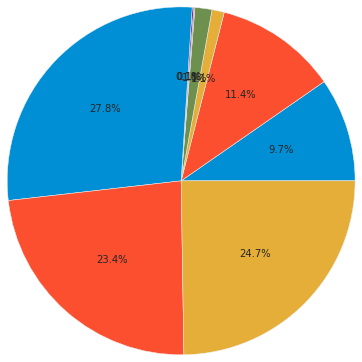

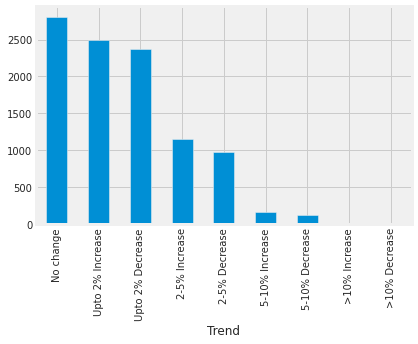

In [14]:

msft_pie_data = msft.groupby('Trend')
#pie_label = msft_pie_data['Trend'].unique()
plt.pie(msft_pie_data['Trend'].count(), #labels = pie_label, 
        autopct = '%1.1f%%', radius = 2 )
plt.show()
ax=msft_pie_data['Trend'].count().sort_values(ascending=False).plot.bar(rot=90)
plt.show()

# [3️⃣. Dataset Visualization Using MPLFinance Plots](#3)>


#### General MPLFinance Plot

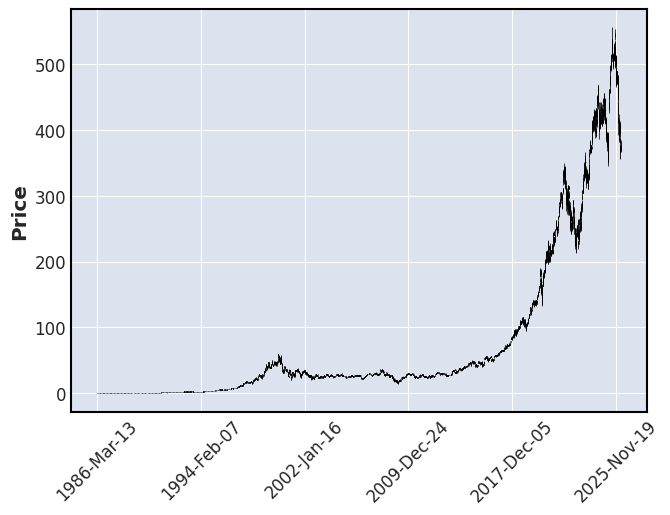

In [15]:
msft.index = pd.DatetimeIndex(msft['Date'])
mpf.plot(msft)

#### CandleStick MPLFinance plot with Moving Averages for (7, 30, 90, 180, 365) days 

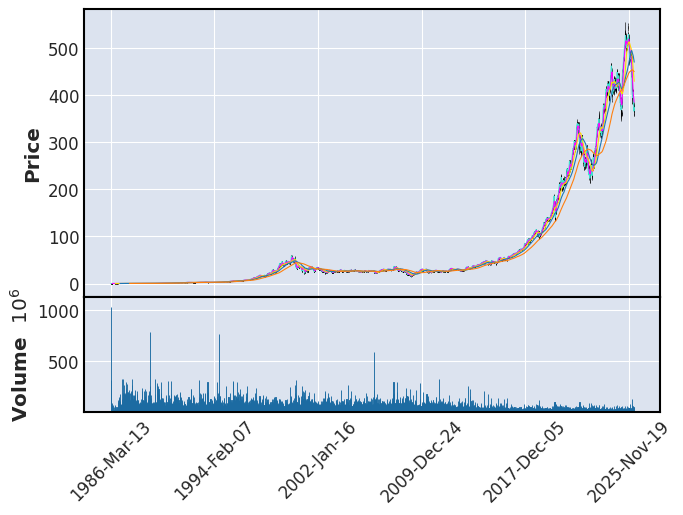

In [16]:
mpf.plot(msft, type='candle', mav = (7, 30, 90, 180, 365), volume = True)

#### Another Candle Stick Plot with Moving Averages and show of non trading days

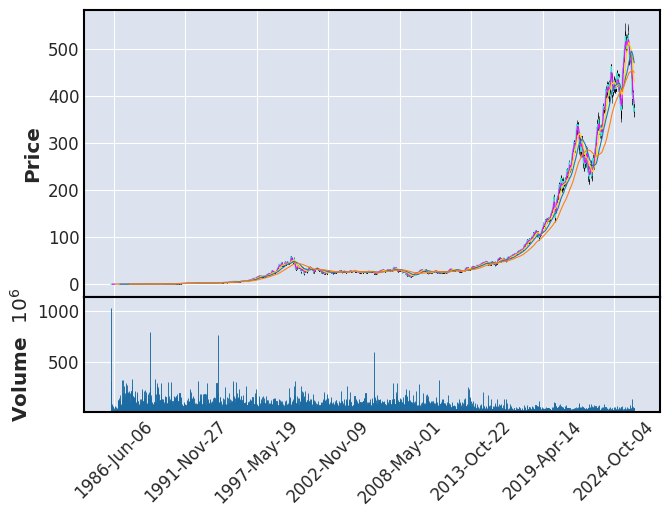

In [17]:
mpf.plot(msft, type='candle', mav = (7, 30, 90, 180, 365), volume = True , show_nontrading = True)

In [18]:
msft.head()

,Date,Adj Close,Close,High,Low,Open,Volume,SMA5,SMA20,SMA50,SMA200,SMA500,EMA5,EMA20,EMA50,EMA200,EMA500,daily_change_pct,returns,Trend
Date,,,,,,,,,,,,,,,,,,,,
1986-03-13,1986-03-13,0.059253,0.097222,0.101563,0.088542,0.088542,1031788800,NaN,NaN,NaN,NaN,NaN,0.097222,0.097222,0.097222,0.097222,0.097222,NaN,NaN,None
1986-03-14,1986-03-14,0.061369,0.100694,0.102431,0.097222,0.097222,308160000,NaN,NaN,NaN,NaN,NaN,0.098379,0.097553,0.097358,0.097257,0.097236,3.571209,35.465951,2-5% Increase
1986-03-17,1986-03-17,0.062428,0.102431,0.103299,0.100694,0.100694,133171200,NaN,NaN,NaN,NaN,NaN,0.099730,0.098017,0.097557,0.097308,0.097257,1.725027,16.840867,Upto 2% Increase
1986-03-18,1986-03-18,0.060840,0.099826,0.103299,0.098958,0.102431,67766400,NaN,NaN,NaN,NaN,NaN,0.099762,0.098190,0.097646,0.097333,0.097267,-2.543174,-25.476069,2-5% Decrease
1986-03-19,1986-03-19,0.059782,0.098090,0.100694,0.097222,0.099826,47894400,0.099653,NaN,NaN,NaN,NaN,0.099205,0.098180,0.097663,0.097341,0.097270,-1.739026,-17.728882,Upto 2% Decrease


# [4️⃣. Stock Analysis of the data](#4)



##### Following is a reuse from the kernel https://www.kaggle.com/datapple/eda-tesla-stock-price-financial-analysis and modified for the analysis

#### Identify the days where the SMA20 is greater than SMA50 and tag the dates.These are target investment dates

In [19]:
msft['Shares'] = [1 if msft.loc[ei, 'SMA20']>msft.loc[ei, 'SMA50'] else 0 for ei in msft.index]

### Tag the dates as profit when the closing price is greater than the preceding date 

#### Plot the dates of wealth generation over the years

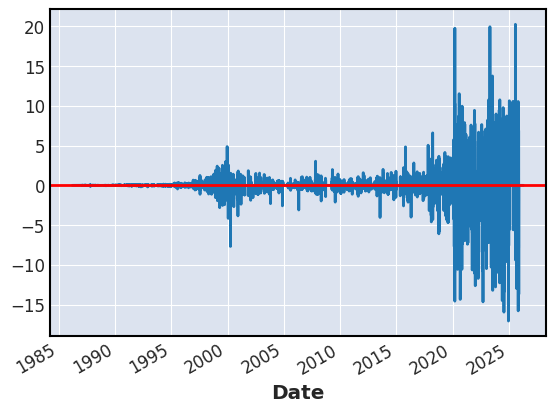

In [20]:
msft['Close1'] = msft['Close'].shift(-1)
msft['Profit'] = [msft.loc[ei, 'Close1'] - msft.loc[ei, 'Close'] if msft.loc[ei, 'Shares']==1 else 0 for ei in msft.index]
msft['Profit'].plot()
plt.axhline(y=0, color='red')

#### Calculate the cumulated wealth on the stock

In [21]:
msft['wealth'] = msft['Profit'].cumsum()
msft.tail()

,Date,Adj Close,Close,High,Low,Open,Volume,SMA5,SMA20,SMA50,...,EMA50,EMA200,EMA500,daily_change_pct,returns,Trend,Shares,Close1,Profit,wealth
Date,,,,,,,,,,,,,,,,,,,,,
2026-04-07,2026-04-07,372.290009,372.290009,372.450012,366.559998,370.339996,21443300,371.634003,381.837000,400.168199,...,401.744016,446.880475,433.181682,-0.158227,-0.000425,No change,0,374.329987,0.0,176.373731
2026-04-08,2026-04-08,374.329987,374.329987,385.000000,371.410004,384.980011,33064800,372.465997,380.265498,398.249199,...,400.668956,446.158579,432.946745,0.547954,0.001464,Upto 2% Increase,0,373.070007,0.0,176.373731
2026-04-09,2026-04-09,373.070007,373.070007,373.500000,367.049988,372.500000,30435300,373.206000,378.674998,396.099000,...,399.586645,445.431330,432.707716,-0.336596,-0.000902,No change,0,370.869995,0.0,176.373731
2026-04-10,2026-04-10,370.869995,370.869995,375.640015,370.029999,372.980011,28038000,372.688000,377.125499,393.883799,...,398.460502,444.689426,432.460859,-0.589705,-0.001590,Upto 2% Decrease,0,380.519989,0.0,176.373731
2026-04-13,2026-04-13,380.519989,380.519989,381.129913,371.019989,373.529999,13667522,374.215997,376.373999,392.824199,...,397.756952,444.050924,432.253510,2.601988,0.006838,2-5% Increase,0,NaN,0.0,176.373731


Text(0.5, 1.0, 'Total money made by Microsoft Stock (number of times ): 176.4')

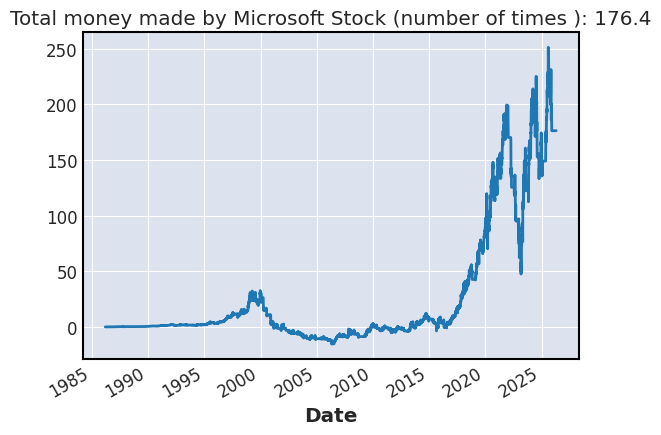

In [22]:
msft['wealth'].plot()
plt.title('Total money made by Microsoft Stock (number of times ): {}'.format(round((msft.loc[msft.index[-2], 'wealth']),1)))

#### Calculate the probability of better investment

In [23]:
msft['LogReturn'] = np.log(msft['Close']).shift(-1) - np.log(msft['Close'])
print(msft['LogReturn'])

Date
1986-03-13    0.035089
1986-03-14    0.017103
1986-03-17   -0.025761
1986-03-18   -0.017543
1986-03-19   -0.026906
                ...   
2026-04-07    0.005465
2026-04-08   -0.003372
2026-04-09   -0.005915
2026-04-10    0.025687
2026-04-13         NaN
Name: LogReturn, Length: 10098, dtype: float64


#### Build a probability distribution function plot using scipy stats package

#### Plot a histogram on logarithm of returns

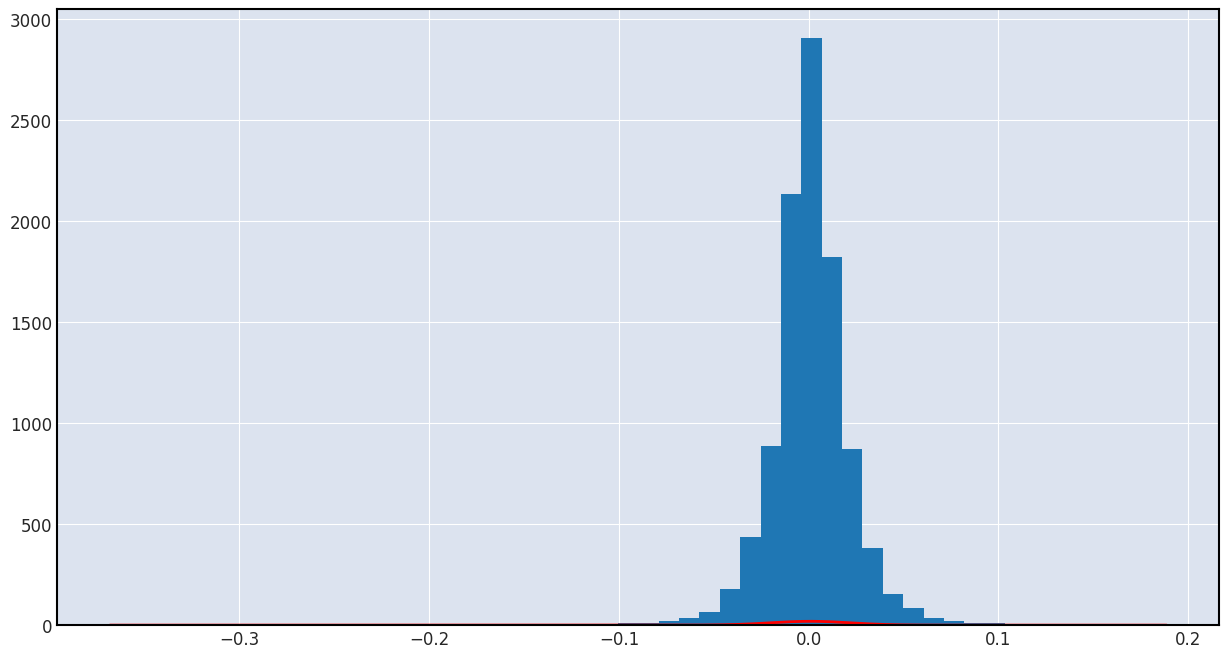

In [24]:
from scipy.stats import norm
mu = msft['LogReturn'].mean()
sigma = msft['LogReturn'].std(ddof=1)

density = pd.DataFrame()
density['x'] = np.arange(msft['LogReturn'].min()-0.01, msft['LogReturn'].max()+0.01, 0.001)
density['pdf'] = norm.pdf(density['x'], mu, sigma)

msft['LogReturn'].hist(bins=50, figsize=(15, 8))
plt.plot(density['x'], density['pdf'], color='red')
plt.show()

#### Check for the probability od drops and jumps for a range

In [25]:
mu220 = 365*mu
sigma220 = (365**0.5) * sigma
for i in range(-5, 6, 1):
    drop = norm.cdf((-i)*0.05, mu220, sigma220)
    jump = norm.cdf(i*0.05, mu220, sigma220)
    print('The probability of %d percent drop is = %f & The probability of %d percent jump is = %f' % (i*5, round(drop,2), -i*5, round(jump,2)))

The probability of -25 percent drop is = 0.450000 & The probability of 25 percent jump is = 0.090000
The probability of -20 percent drop is = 0.400000 & The probability of 20 percent jump is = 0.110000
The probability of -15 percent drop is = 0.360000 & The probability of 15 percent jump is = 0.130000
The probability of -10 percent drop is = 0.310000 & The probability of 10 percent jump is = 0.160000
The probability of -5 percent drop is = 0.270000 & The probability of 5 percent jump is = 0.190000
The probability of 0 percent drop is = 0.230000 & The probability of 0 percent jump is = 0.230000
The probability of 5 percent drop is = 0.190000 & The probability of -5 percent jump is = 0.270000
The probability of 10 percent drop is = 0.160000 & The probability of -10 percent jump is = 0.310000
The probability of 15 percent drop is = 0.130000 & The probability of -15 percent jump is = 0.360000
The probability of 20 percent drop is = 0.110000 & The probability of -20 percent jump is = 0.4000

#### What is the Value At Risk for the Stock?

In [26]:
VaR = norm.ppf(0.05, mu, sigma)
print('Single day value at risk is: ', VaR)

Single day value at risk is:  -0.03370147610042296


#### What is the Mu and Sigma for the stock at 5 and 95 percentile?

In [27]:
# Quantile 
# 5% quantile
print('5% quantile ', norm.ppf(0.05, mu, sigma))
# 95% quantile
print('95% quantile ', norm.ppf(0.95, mu, sigma))

5% quantile  -0.03370147610042296
95% quantile  0.035340041409214894


#### What is the confidence level at various levels?

In [28]:
msft['logReturn'] = np.log(msft['Close'].shift(-1)) - np.log(msft['Close'])
sample_size = msft['logReturn'].shape[0]
sample_mean = msft['logReturn'].mean()
sample_std = msft['logReturn'].std(ddof=1) / sample_size**0.5
# left and right quantile
for i in range(1,10):
    z_left = norm.ppf(0.05*i)
    z_right = norm.ppf((1-0.05*i))
    interval_left = sample_mean+z_left*sample_std
    interval_right = sample_mean+z_right*sample_std
    print('%d percent confidence interval is ' % (100-i*2*5), ( round(interval_left,6), round(interval_right,6)))

90 percent confidence interval is  (0.000476, 0.001163)
80 percent confidence interval is  (0.000552, 0.001087)
70 percent confidence interval is  (0.000603, 0.001036)
60 percent confidence interval is  (0.000644, 0.000995)
50 percent confidence interval is  (0.000678, 0.00096)
40 percent confidence interval is  (0.00071, 0.000929)
30 percent confidence interval is  (0.000739, 0.0009)
20 percent confidence interval is  (0.000766, 0.000872)
10 percent confidence interval is  (0.000793, 0.000846)


# [5️⃣ Let us do a financial ratios calculation using FINTA library](#5)a>


* Simple Moving Average 'SMA'
* Simple Moving Median 'SMM'
* Smoothed Simple Moving Average 'SSMA'
* Exponential Moving Average 'EMA'
* Double Exponential Moving Average 'DEMA'
* Triple Exponential Moving Average 'TEMA'
* Triangular Moving Average 'TRIMA'
* Triple Exponential Moving Average Oscillator 'TRIX'
* Volume Adjusted Moving Average 'VAMA'
* Kaufman Efficiency Indicator 'ER'
* Kaufman's Adaptive Moving Average 'KAMA'
* Zero Lag Exponential Moving Average 'ZLEMA'
* Weighted Moving Average 'WMA'
* Hull Moving Average 'HMA'
* Elastic Volume Moving Average 'EVWMA'
* Volume Weighted Average Price 'VWAP'
* Smoothed Moving Average 'SMMA'
* Fractal Adaptive Moving Average 'FRAMA'
* Moving Average Convergence Divergence 'MACD'
* Percentage Price Oscillator 'PPO'
* Volume-Weighted MACD 'VW_MACD'
* Elastic-Volume weighted MACD 'EV_MACD'
* Market Momentum 'MOM'
* Rate-of-Change 'ROC'
* Relative Strenght Index 'RSI'
* Inverse Fisher Transform RSI 'IFT_RSI'
* True Range 'TR'
* Average True Range 'ATR'
* Stop-and-Reverse 'SAR'
* Bollinger Bands 'BBANDS'
* Bollinger Bands Width 'BBWIDTH'
* Momentum Breakout Bands 'MOBO'
* Percent B 'PERCENT_B'
* Keltner Channels 'KC'
* Donchian Channel 'DO'
* Directional Movement Indicator 'DMI'
* Average Directional Index 'ADX'
* Pivot Points 'PIVOT'
* Fibonacci Pivot Points 'PIVOT_FIB'
* Stochastic Oscillator %K 'STOCH'
* Stochastic oscillator %D 'STOCHD'
* Stochastic RSI 'STOCHRSI'
* Williams %R 'WILLIAMS'
* Ultimate Oscillator 'UO'
* Awesome Oscillator 'AO'
* Mass Index 'MI'
* Vortex Indicator 'VORTEX'
* Know Sure Thing 'KST'
* True Strength Index 'TSI'
* Typical Price 'TP'
* Accumulation-Distribution Line 'ADL'
* Chaikin Oscillator 'CHAIKIN'
* Money Flow Index 'MFI'
* On Balance Volume 'OBV'
* Weighter OBV 'WOBV'
* Volume Zone Oscillator 'VZO'
* Price Zone Oscillator 'PZO'
* Elder's Force Index 'EFI'
* Cummulative Force Index 'CFI'
* Bull power and Bear Power 'EBBP'
* Ease of Movement 'EMV'
* Commodity Channel Index 'CCI'
* Coppock Curve 'COPP'
* Buy and Sell Pressure 'BASP'
* Normalized BASP 'BASPN'
* Chande Momentum Oscillator 'CMO'
* Chandelier Exit 'CHANDELIER'
* Qstick 'QSTICK'
* Twiggs Money Index 'TMF'
* Wave Trend Oscillator 'WTO'
* Fisher Transform 'FISH'
* Ichimoku Cloud 'ICHIMOKU'
* Adaptive Price Zone 'APZ'
* Squeeze Momentum Indicator 'SQZMI'
* Volume Price Trend 'VPT'
* Finite Volume Element 'FVE'
* Volume Flow Indicator 'VFI'
* Moving Standard deviation 'MSD'
* Schaff Trend Cycle 'STC'


In [29]:
try:
    from finta import TA
    from backtesting import Backtest, Strategy
    from backtesting.lib import crossover
except:
    !pip install finta backtesting
    from finta import TA
    from backtesting import Backtest, Strategy
    from backtesting.lib import crossover


     |████████████████████████████████| 178 kB 6.3 MB/s 


Loading BokehJS ...

In [30]:
fin_msft = pd.read_csv('../input/microsoft-stock-details-updated-regularly/Microsoft_stock_history.csv', index_col="Date", parse_dates=True)
print(fin_msft.head())
ohlc=fin_msft
print(TA.SMA(ohlc, 42))
#will return Pandas Series object with "Awesome oscillator" values
TA.AO(ohlc)
#expects ["volume"] column as input
print(TA.OBV(ohlc))
#will return Series with Bollinger Bands columns [BB_UPPER, BB_LOWER]
print(TA.BBANDS(ohlc))
#will return Series with calculated BBANDS values but will use KAMA instead of MA for calculation, other types of Moving Averages are allowed as well.
print(TA.BBANDS(ohlc, MA=TA.KAMA(ohlc, 20)))

            Adj Close     Close      High       Low      Open      Volume
Date                                                                     
1986-03-13   0.059253  0.097222  0.101563  0.088542  0.088542  1031788800
1986-03-14   0.061369  0.100694  0.102431  0.097222  0.097222   308160000
1986-03-17   0.062428  0.102431  0.103299  0.100694  0.100694   133171200
1986-03-18   0.060840  0.099826  0.103299  0.098958  0.102431    67766400
1986-03-19   0.059782  0.098090  0.100694  0.097222  0.099826    47894400
Date
1986-03-13           NaN
1986-03-14           NaN
1986-03-17           NaN
1986-03-18           NaN
1986-03-19           NaN
                 ...    
2026-04-07    391.984762
2026-04-08    391.524285
2026-04-09    390.855951
2026-04-10    389.838570
2026-04-13    389.058808
Name: 42 period SMA, Length: 10098, dtype: float64
Date
1986-03-13             NaN
1986-03-14    3.081600e+08
1986-03-17    4.413312e+08
1986-03-18    3.735648e+08
1986-03-19    3.256704e+08
           

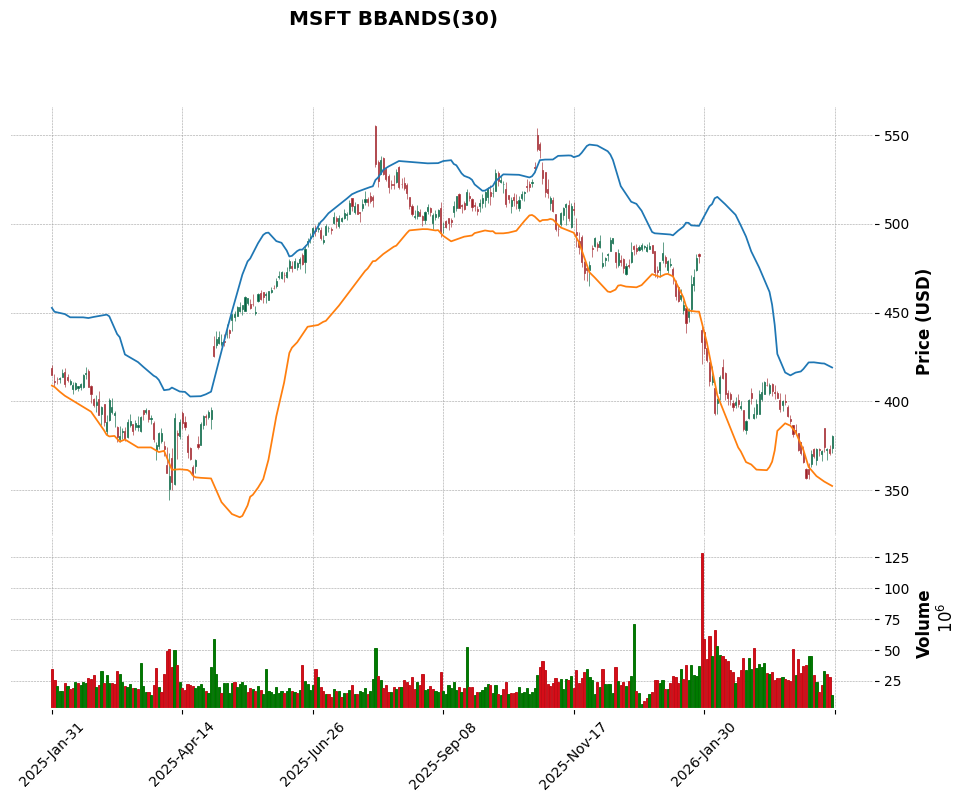

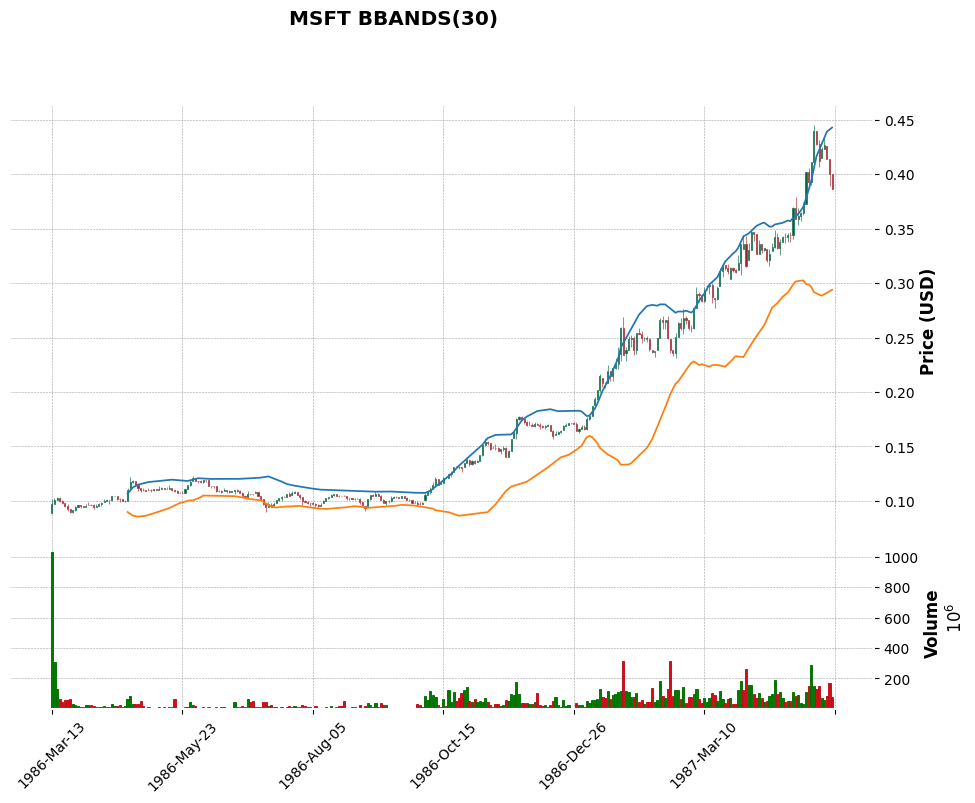

In [31]:

# calc bol band
bbands = TA.BBANDS(fin_msft, 30)

# cherry pick what to show on the chart
bands_plot = pd.concat([bbands.BB_UPPER, bbands.BB_LOWER], axis=1)

apd = mpf.make_addplot(bands_plot.tail(300))

mpf.plot(fin_msft.tail(300), type='candle', style='charles',
        title='MSFT BBANDS(30)',
        ylabel='Price (USD)',
        ylabel_lower='Volume',
        volume=True,
        figscale=1.5,
        addplot=apd
        )

apd = mpf.make_addplot(bands_plot.head(300))

mpf.plot(fin_msft.head(300), type='candle', style='charles',
        title='MSFT BBANDS(30)',
        ylabel='Price (USD)',
        ylabel_lower='Volume',
        volume=True,
        figscale=1.5,
        addplot=apd
        )

Plotting .... TA.SMA(ohlc).plot(title=' Simple Moving Average ')
Plotting .... TA.SMM(ohlc).plot(title=' Simple Moving Median ')
Plotting .... TA.SSMA(ohlc).plot(title=' Smoothed Simple Moving Average ')
Plotting .... TA.EMA(ohlc).plot(title=' Exponential Moving Average ')
Plotting .... TA.DEMA(ohlc).plot(title=' Double Exponential Moving Average ')
Plotting .... TA.TEMA(ohlc).plot(title=' Triple Exponential Moving Average ')
Plotting .... TA.TRIMA(ohlc).plot(title=' Triangular Moving Average ')
Plotting .... TA.TRIX(ohlc).plot(title=' Triple Exponential Moving Average Oscillator ')
Plotting .... TA.VAMA(ohlc).plot(title=' Volume Adjusted Moving Average ')
Plotting .... TA.ER(ohlc).plot(title=' Kaufman Efficiency Indicator ')
Plotting .... TA.KAMA(ohlc).plot(title=' Kaufmans Adaptive Moving Average ')
Plotting .... TA.ZLEMA(ohlc).plot(title=' Zero Lag Exponential Moving Average ')
Plotting .... TA.WMA(ohlc).plot(title=' Weighted Moving Average ')
Plotting .... TA.HMA(ohlc).plot(title='

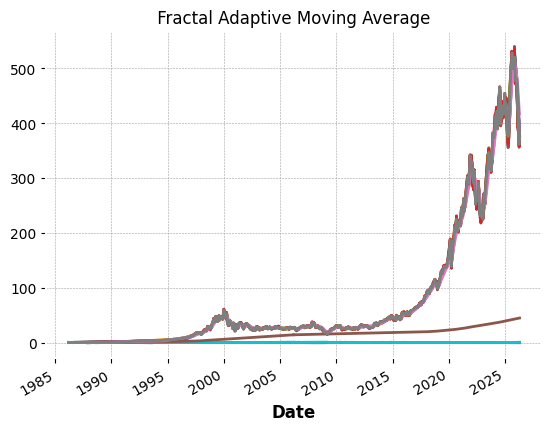

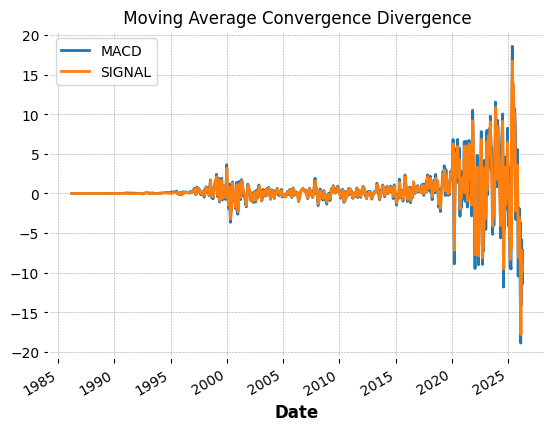

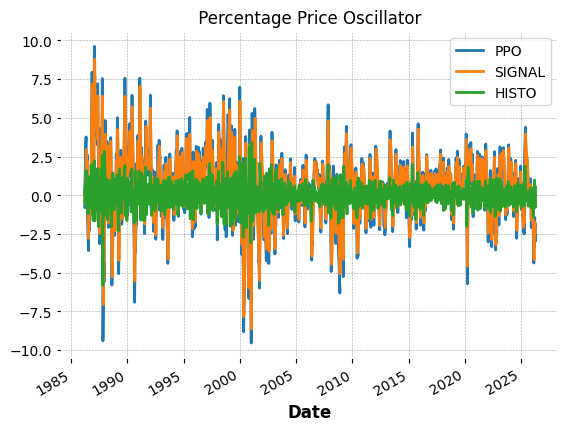

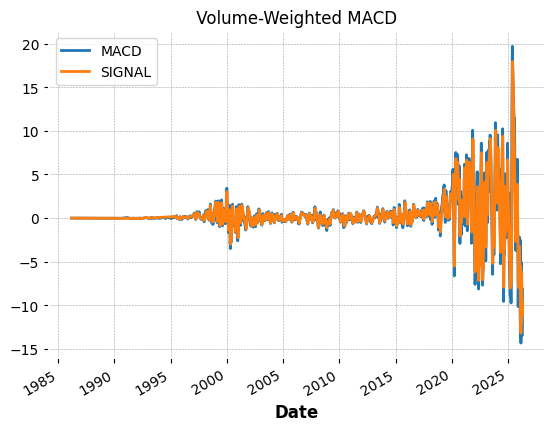

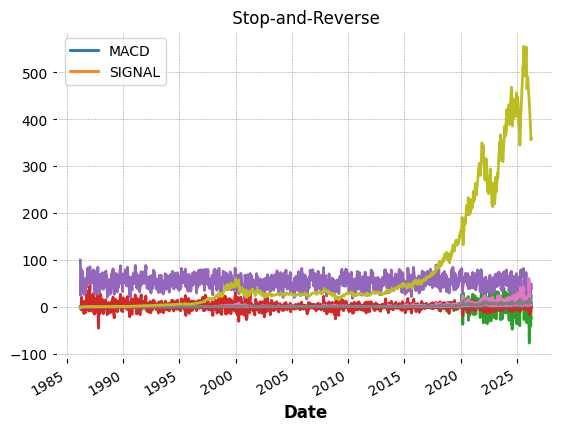

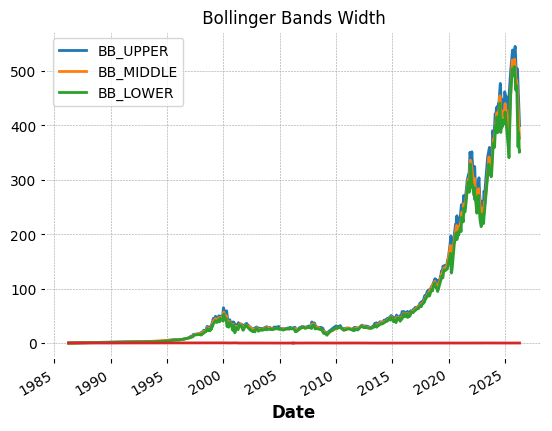

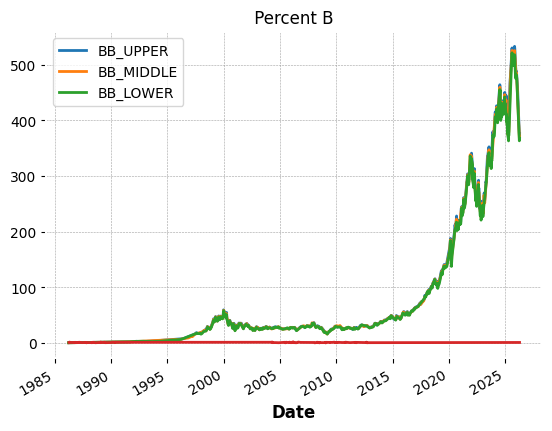

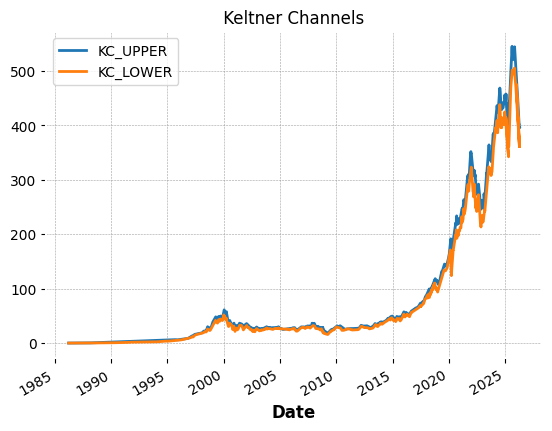

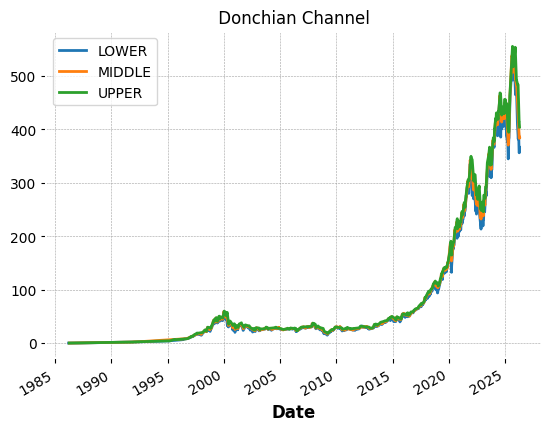

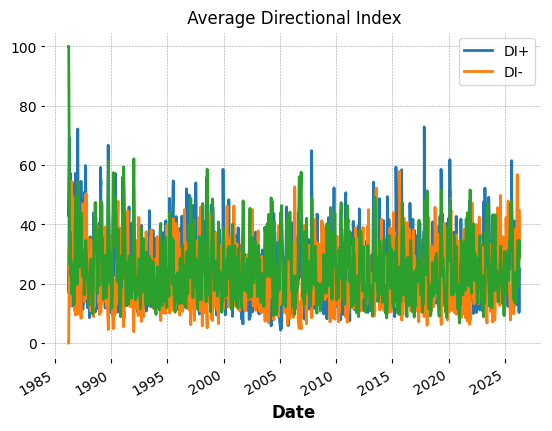

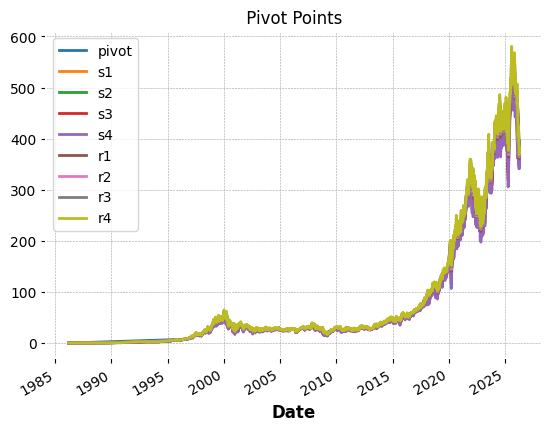

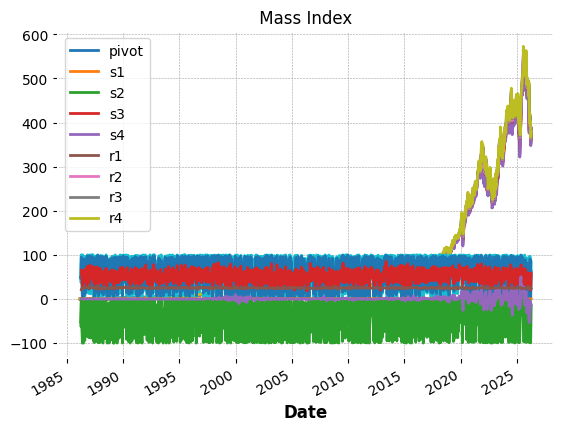

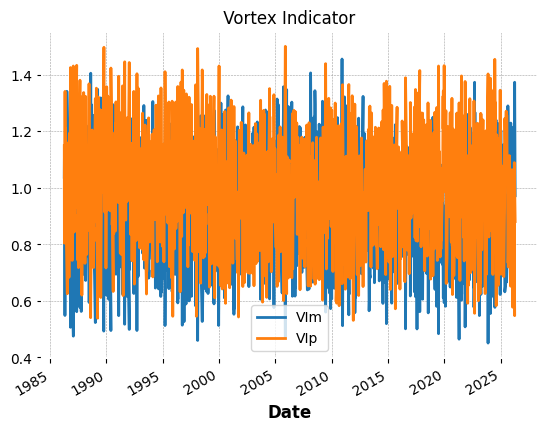

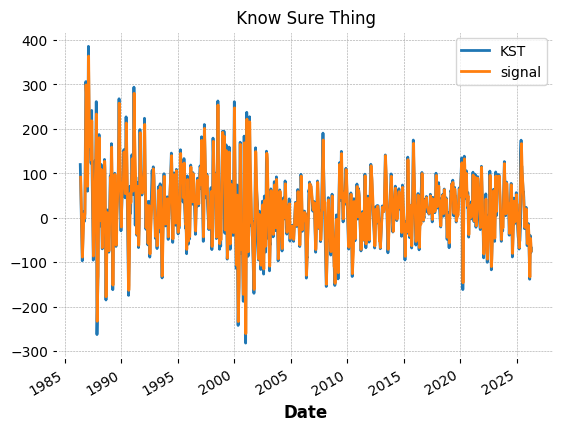

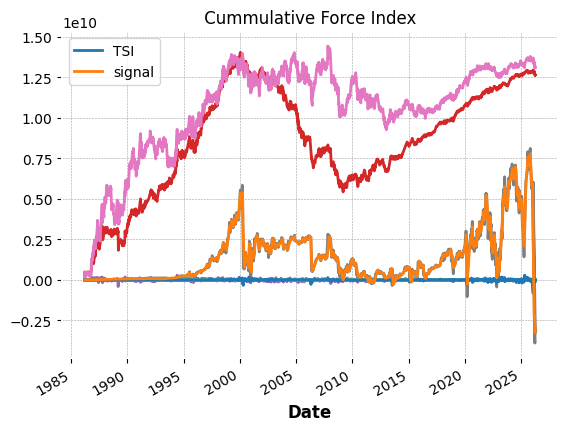

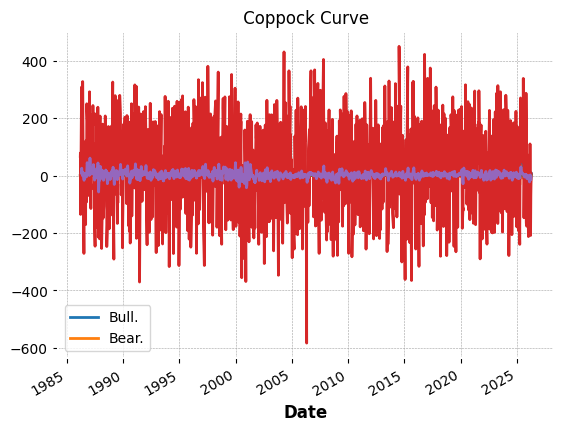

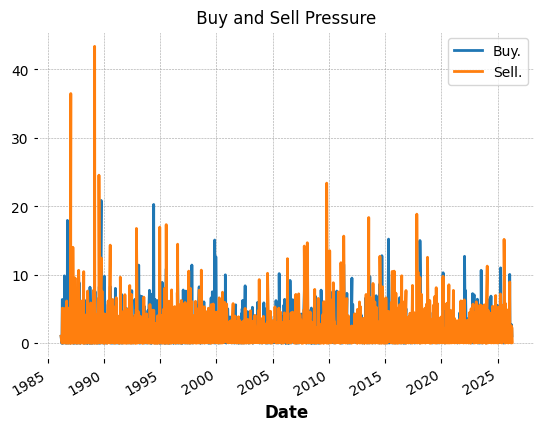

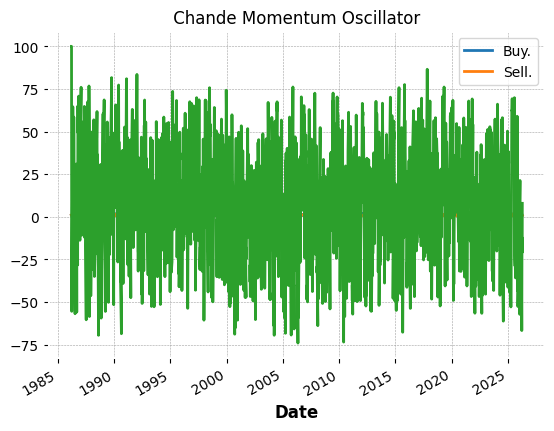

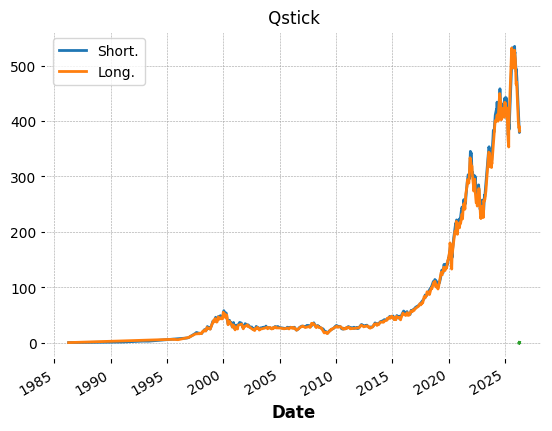

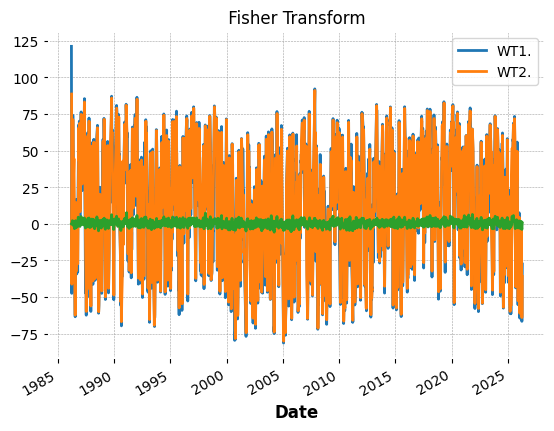

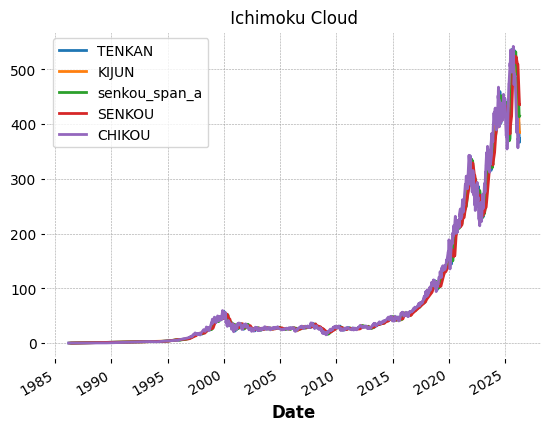

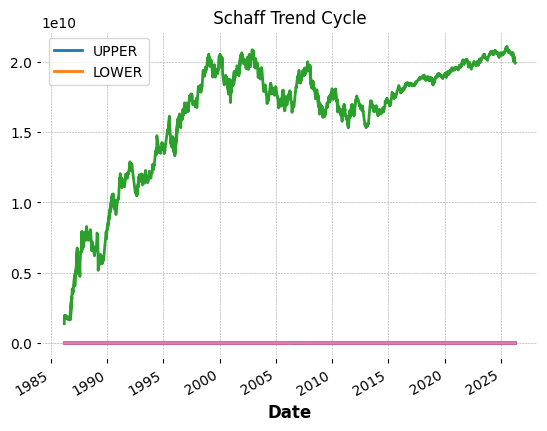

In [32]:

function_dict = {' Simple Moving Average ' : 'SMA',
                 ' Simple Moving Median ' : 'SMM',
                 ' Smoothed Simple Moving Average ' : 'SSMA',
                 ' Exponential Moving Average ' : 'EMA',
                 ' Double Exponential Moving Average ' : 'DEMA',
                 ' Triple Exponential Moving Average ' : 'TEMA',
                 ' Triangular Moving Average ' : 'TRIMA',
                 ' Triple Exponential Moving Average Oscillator ' : 'TRIX',
                 ' Volume Adjusted Moving Average ' : 'VAMA',
                 ' Kaufman Efficiency Indicator ' : 'ER',
                 ' Kaufmans Adaptive Moving Average ' : 'KAMA',
                 ' Zero Lag Exponential Moving Average ' : 'ZLEMA',
                 ' Weighted Moving Average ' : 'WMA',
                 ' Hull Moving Average ' : 'HMA',
                 ' Elastic Volume Moving Average ' : 'EVWMA',
                 ' Volume Weighted Average Price ' : 'VWAP',
                 ' Smoothed Moving Average ' : 'SMMA',
                 ' Fractal Adaptive Moving Average ' : 'FRAMA',
                 ' Moving Average Convergence Divergence ' : 'MACD',
                 ' Percentage Price Oscillator ' : 'PPO',
                 ' Volume-Weighted MACD ' : 'VW_MACD',
                 ' Elastic-Volume weighted MACD ' : 'EV_MACD',
                 ' Market Momentum ' : 'MOM',
                 ' Rate-of-Change ' : 'ROC',
                 ' Relative Strength Index ' : 'RSI',
                 ' Inverse Fisher Transform RSI ' : 'IFT_RSI',
                 ' True Range ' : 'TR',
                 ' Average True Range ' : 'ATR',
                 ' Stop-and-Reverse ' : 'SAR',
                 ' Bollinger Bands ' : 'BBANDS',
                 ' Bollinger Bands Width ' : 'BBWIDTH',
                 ' Momentum Breakout Bands ' : 'MOBO',
                 ' Percent B ' : 'PERCENT_B',
                 ' Keltner Channels ' : 'KC',
                 ' Donchian Channel ' : 'DO',
                 ' Directional Movement Indicator ' : 'DMI',
                 ' Average Directional Index ' : 'ADX',
                 ' Pivot Points ' : 'PIVOT',
                 ' Fibonacci Pivot Points ' : 'PIVOT_FIB',
                 ' Stochastic Oscillator Percent K ' : 'STOCH',
                 ' Stochastic oscillator Percent D ' : 'STOCHD',
                 ' Stochastic RSI ' : 'STOCHRSI',
                 ' Williams Percent R ' : 'WILLIAMS',
                 ' Ultimate Oscillator ' : 'UO',
                 ' Awesome Oscillator ' : 'AO',
                 ' Mass Index ' : 'MI',
                 ' Vortex Indicator ' : 'VORTEX',
                 ' Know Sure Thing ' : 'KST',
                 ' True Strength Index ' : 'TSI',
                 ' Typical Price ' : 'TP',
                 ' Accumulation-Distribution Line ' : 'ADL',
                 ' Chaikin Oscillator ' : 'CHAIKIN',
                 ' Money Flow Index ' : 'MFI',
                 ' On Balance Volume ' : 'OBV',
                 ' Weighter OBV ' : 'WOBV',
                 ' Volume Zone Oscillator ' : 'VZO',
                 ' Price Zone Oscillator ' : 'PZO',
                 ' Elders Force Index ' : 'EFI',
                 ' Cummulative Force Index ' : 'CFI',
                 ' Bull power and Bear Power ' : 'EBBP',
                 ' Ease of Movement ' : 'EMV',
                 ' Commodity Channel Index ' : 'CCI',
                 ' Coppock Curve ' : 'COPP',
                 ' Buy and Sell Pressure ' : 'BASP',
                 ' Normalized BASP ' : 'BASPN',
                 ' Chande Momentum Oscillator ' : 'CMO',
                 ' Chandelier Exit ' : 'CHANDELIER',
                 ' Qstick ' : 'QSTICK',
                 #' Twiggs Money Index ' : 'TMF',
                 ' Wave Trend Oscillator ' : 'WTO',
                 ' Fisher Transform ' : 'FISH',
                 ' Ichimoku Cloud ' : 'ICHIMOKU',
                 ' Adaptive Price Zone ' : 'APZ',
                 #' Squeeze Momentum Indicator ' : 'SQZMI',
                 ' Volume Price Trend ' : 'VPT',
                 ' Finite Volume Element ' : 'FVE',
                 ' Volume Flow Indicator ' : 'VFI',
                 ' Moving Standard deviation ' : 'MSD',
                 ' Schaff Trend Cycle ' : 'STC'}

for key, value in function_dict .items():
    function_name = "TA." + value + "(ohlc).plot(title='" + key + "')"
    print('Plotting ....' , function_name)
    result = eval(function_name)


## Plot the EMA Averages

<AxesSubplot:xlabel='Date'>

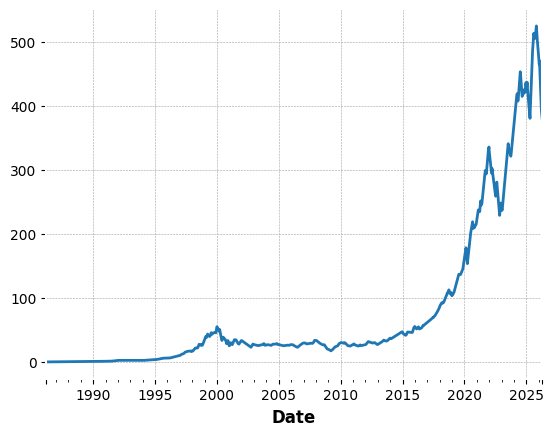

In [33]:
from finta.utils import resample_calendar
fin_ohlc = ohlc[['Close', 'Volume', 'Open', 'High', 'Low']]
fin_ohlc.columns = ['close', 'volume', 'open', 'high', 'low']
fin_ohlc["close"] = ohlc["Close"]#.apply(split)
fin_ohlc["low"] = ohlc["Low"]#.apply(split)
fin_ohlc["high"] = ohlc["High"]#.apply(split)
fin_ohlc["open"] = ohlc["Open"]#.apply(split)
fin_ohlc["volume"] = ohlc["Volume"]

weekly_ohlc = resample_calendar(fin_ohlc, "7d")
TA.EMA(weekly_ohlc, 5).plot()

## Use backtesting library to do a simple data backtesting

In [34]:
# Defining DEMA cross strategy
class DemaCross(Strategy):

    def init(self):

        self.ma1 = self.I(TA.DEMA, ohlc, 10)
        self.ma2 = self.I(TA.DEMA, ohlc, 20)

    def next(self):
        if crossover(self.ma1, self.ma2):
            self.buy()
        elif crossover(self.ma2, self.ma1):
            self.sell()

In [35]:
bt = Backtest(ohlc, DemaCross,
              cash=10000, commission=0.025)

### Let us check the Backtesting summary

In [36]:
bt.run()

Start                     1986-03-13 00:00:00
End                       2026-04-13 00:00:00
Duration                  14641 days 00:00:00
Exposure Time [%]                    2.030105
Equity Final [$]                          0.0
Equity Peak [$]                  10724.572644
Return [%]                             -100.0
Buy & Hold Return [%]           391292.881861
Return (Ann.) [%]                         0.0
Volatility (Ann.) [%]              413.009994
Sharpe Ratio                              0.0
Sortino Ratio                             0.0
Calmar Ratio                              0.0
Max. Drawdown [%]                      -100.0
Avg. Drawdown [%]                   -50.39024
Max. Drawdown Duration    14630 days 00:00:00
Avg. Drawdown Duration     7316 days 00:00:00
# Trades                                    3
Win Rate [%]                        33.333333
Best Trade [%]                       1.894939
Worst Trade [%]                   -100.630044
Avg. Trade [%]                    

## It is very evidend that albeit some volatility, it is a pretty solid long term stock with outstanding run over last 5 years.

> 

# [6️⃣ Let us do a financial ratios calculation](#6)


### Let us try Sharpe Ratio

In [37]:
def sharpe_ratio(return_series, N, rf):
    mean = return_series.mean() * N -rf
    sigma = return_series.std() * np.sqrt(N)
    return mean / sigma

N = 255 #255 trading days in a year
rf =0.018 #1.8% risk free rate
msft.columns
temp_df=msft[['Close']]
sharpes = temp_df.apply(sharpe_ratio, args=(N,rf,))#,axis=0)
print("The Sharpe Ratio for the stock i =" , round(sharpes[0],2))

The Sharpe Ratio for the stock i = 10.11


In [38]:
def calculate_sortino(series,N, rf):
    expected_return = np.mean(series)
    below_avg = [i for i in series if i < expected_return]
    risk_free = rf
    sortino = (expected_return - risk_free) / np.std(below_avg)
    return round(sortino, 2)

sortinos = temp_df.apply(calculate_sortino, args=(N,rf,))
print("The Sortino Ratio for the stock is =" , round(sortinos[0],2))

The Sortino Ratio for the stock is = 4.3


In [39]:
def max_drawdown(return_series):
    comp_ret = (return_series+1).cumprod()
    peak = comp_ret.expanding(min_periods=1).max()
    dd = (comp_ret/peak)-1
    return dd.min()


max_drawdowns = temp_df.apply(max_drawdown,axis=0)
print("The max_drawdowns Ratio for the stock is =" , round(max_drawdowns[0],2))

The max_drawdowns Ratio for the stock is = 0.0


## Try Bollinger Bands Price

In [40]:
def bollinger_bands_price(price):
    up, mid, low = BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
    bollinger_bands_price = (price['Close'] - low) / (up - low)
    return bollinger_bands_price

# [7️⃣ Let us do a bit of forecasting using Regression ](#7)

 Some inspiration from the following post as well
*  [MLQ.AI](https://www.mlq.ai/price-prediction-with-linear-regression/)


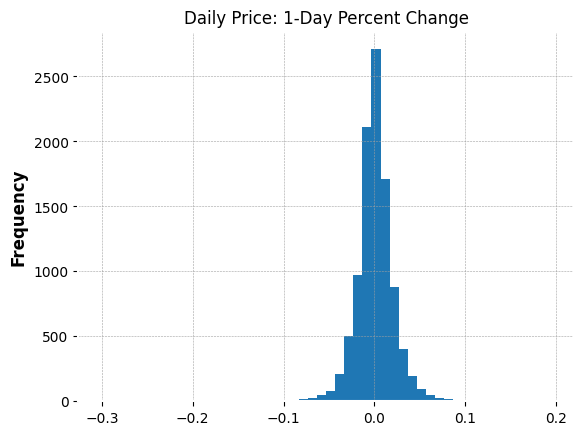

In [41]:
# Histogram of the daily price change percent of 'Close' price
msft['Close'].pct_change().plot.hist(bins=50)
plt.title('Daily Price: 1-Day Percent Change')
plt.show() 

In [42]:
# Create 5-day % changes of Last for the current day, and 5 days in the future
msft['5d_future_close'] = msft['Close'].shift(-5)
msft['5d_close_future_pct'] = msft['5d_future_close'].pct_change(5)
msft['5d_close_pct'] = msft['Close'].pct_change(5)

In [43]:
# Calculate the correlation matrix between the 5d close pecentage changes (current and future)
corr = msft[['5d_close_pct', '5d_close_future_pct']].corr()

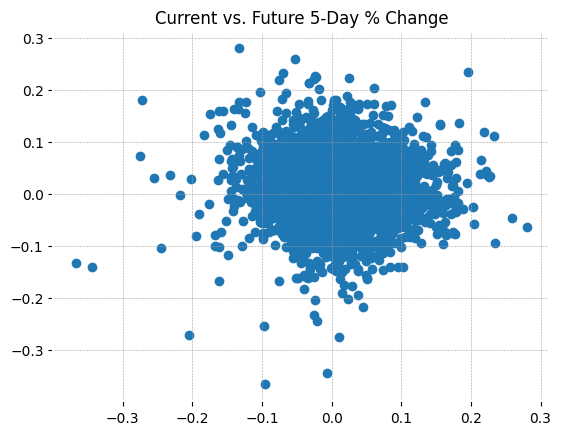

In [44]:
# Scatter the current 5-day percent change vs the future 5-day percent change
plt.scatter(msft['5d_close_pct'], msft['5d_close_future_pct'])
plt.title('Current vs. Future 5-Day % Change')
plt.show()

In [45]:
# a list of the feature names for later
feature_names = ['5d_close_pct']  

In [46]:
# Drop all na values
msft = msft.dropna()

# Create features and targets
# use feature_names for features; 5d_close_future_pct for targets
features = msft[feature_names]
targets = msft['5d_close_future_pct']

# Create DataFrame from target column and feature columns
feat_targ_df = msft[['5d_close_future_pct'] + feature_names]

# Calculate correlation matrix
corr = feat_targ_df.corr()
print(corr)

                     5d_close_future_pct  5d_close_pct
5d_close_future_pct             1.000000     -0.058012
5d_close_pct                   -0.058012      1.000000


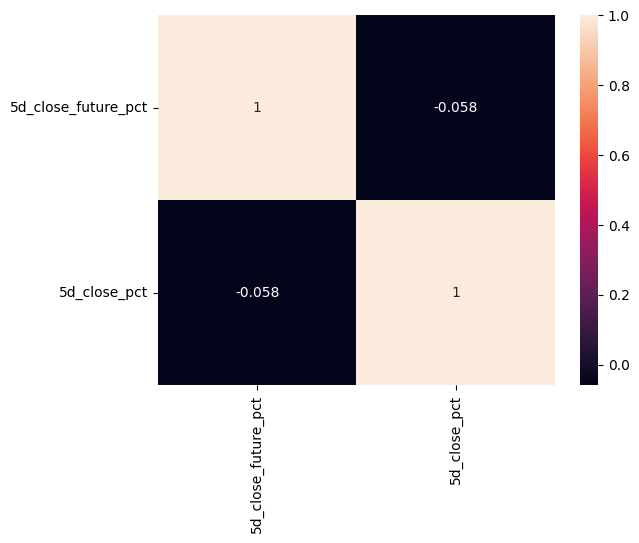

In [47]:
import seaborn as sns
# Plot heatmap of correlation matrix
sns.heatmap(corr, annot=True)
plt.yticks(rotation=0); plt.xticks(rotation=90) # fix ticklabel directions
plt.show() # show the plot

In [48]:
import statsmodels.api as sm

# Add a constant to the features
linear_features = sm.add_constant(features)

# Create a size for the training set that is 80% of the total number of rows
#.shape gives us the number of rows in our data, and convert to an int
train_size = int(0.8 * features.shape[0])

# split features and targets using python indexing
train_features = linear_features[:train_size]
train_targets = targets[:train_size]
test_features = linear_features[train_size:]
test_targets = targets[train_size:]
print(linear_features.shape, train_features.shape, test_features.shape)

(9594, 2) (7675, 2) (1919, 2)


In [49]:
# Create the linear model and complete the least squares fit
model = sm.OLS(train_targets, train_features)
results = model.fit()  # fit the model
print(results.summary())

# examine pvalues
# Features with p <= 0.05 are typically considered significantly different from 0
print(results.pvalues)

# Make predictions from our model for train and test sets
train_predictions = results.predict(train_features)
test_predictions = results.predict(test_features)

                             OLS Regression Results                            
Dep. Variable:     5d_close_future_pct   R-squared:                       0.003
Model:                             OLS   Adj. R-squared:                  0.003
Method:                  Least Squares   F-statistic:                     24.66
Date:                 Thu, 16 Apr 2026   Prob (F-statistic):           6.98e-07
Time:                         11:46:32   Log-Likelihood:                 13200.
No. Observations:                 7675   AIC:                        -2.640e+04
Df Residuals:                     7673   BIC:                        -2.638e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0048      0.000    

# [8️⃣ Let us do a Forecasting using FB Prophet ](#8)


# Use of Facebook Prophet for Stock Forecasting
## MICROSOFT Stock forecast 
* This kernel uses Facebook Prophet (which uses SKLEARN) and Neural Prophet (which uses PyTorch) libaries to predict stocks. This kernel splits the NASDAQ stocks into ten folds and creates 10 output files each for the stocks in a PDF Format

###  Yahoo! DataReader Download
<div class="alert alert-block alert-info">
<b>Step-1:</b> Download data using Yahoo! Finance Data Reader</div>

###  Facebook Prophet Models
<div class="alert alert-block alert-info">
<b>Step-2:</b> Build Facebook Prophet Input dataset</div>
<div class="alert alert-block alert-info">
<b>Step-3:</b> Run Prophet Model</div>
<div class="alert alert-block alert-info">
<b>Step-4:</b> Generate Model Visualization </div>
<div class="alert alert-block alert-info">
<b>Step-5:</b> Generate the Image Files </div>
<div class="alert alert-block alert-info">
<b>Step-6:</b> Consolidate Image Files for Facebook Prophet Model </div>

###  Neural Prophet Models
<div class="alert alert-block alert-warning">
<b>Step-7-11:</b> Repeat Steps 2-6 for Neural Prophet Model </div>



In [50]:
try:
    from fbprophet.plot import plot_plotly
    from fbprophet import Prophet
except:
    !pip install fbprophet    # install Faceboo Prophet
    from fbprophet.plot import plot_plotly
    from fbprophet import Prophet
    

In [51]:
from fbprophet.plot import plot_plotly
from fbprophet import Prophet

In [52]:
def plot_close_val(data_frame, column, stock):
    plt.figure(figsize=(16,6))
    plt.title(column + ' Price History for ' + stock )
    plt.plot(data_frame[column])
    plt.xlabel('Date', fontsize=18)
    plt.ylabel(column + ' Price USD ($) for ' + stock, fontsize=18)
    plt.show()

In [53]:
def fb_prophet_plot(df, param, stock):
    # Check the dataset
    #df.head()
    # Create Dataset based on the FB Prophet standard ds/y
    df2 = pd.DataFrame([], columns = ['ds', 'y'])
    df2.columns=['ds','y']
    df2['ds']=pd.to_datetime(df.index,format='%Y-%m')
    #Assign the Parameter
    df2['y']=df[param].values
    #check the new DS
    #df2.head()
    
    #create a new Prophet Model
    model=Prophet(interval_width=0.95,yearly_seasonality=True)
    
    #Fit the Model
    model.fit(df2)
    #Predict the future
    future=model.make_future_dataframe(periods=50, freq='MS')
    forecast=model.predict(future)
    #Save the predicted model
    preds= forecast['yhat'][:-50]
    #plot the graph
    title = 'FB Prophet predictions for ==> ' + stock
    plt.figure(figsize=(16,8))
    plt.plot(df2.ds,preds,color='#555555',label=' Predictions')
    plt.plot(df2.ds,df2.y,color='#1155FF',label='Actual')
    plt.title(title)
    plt.legend()
    plt.show()
    figure=model.plot(forecast,xlabel='Date',ylabel='Price')
    figure.set_size_inches(16,8)
    plt.title(title)
    model.plot_components(forecast)
    plt.show()

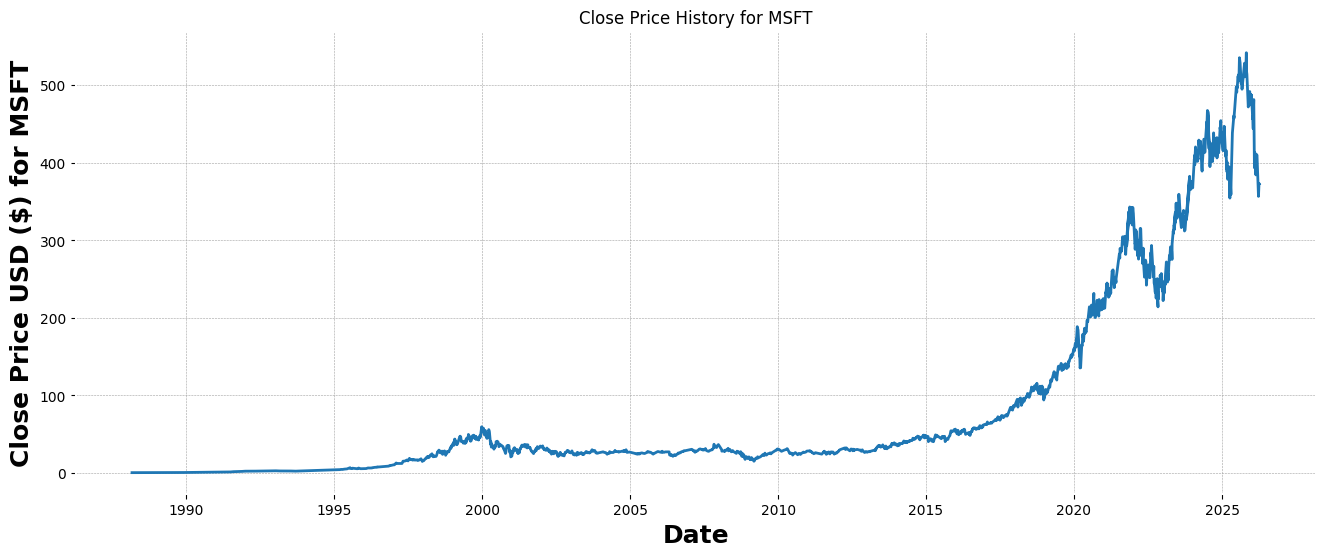

Initial log joint probability = -304.209
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
      99       28144.7    0.00101422       8038.74      0.5903      0.5903      125   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     199         28550    0.00914066       3974.84      0.8161      0.8161      245   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     299       28621.9    0.00113796       1071.18      0.5931      0.5931      360   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     399       28666.4    0.00256845        336.77           1           1      475   
    Iter      log prob        ||dx||      ||grad||       alpha      alpha0  # evals  Notes 
     499       28675.7    0.00208643       425.889           1           1      593   
    Iter      log prob        ||dx||      ||grad||       alpha  

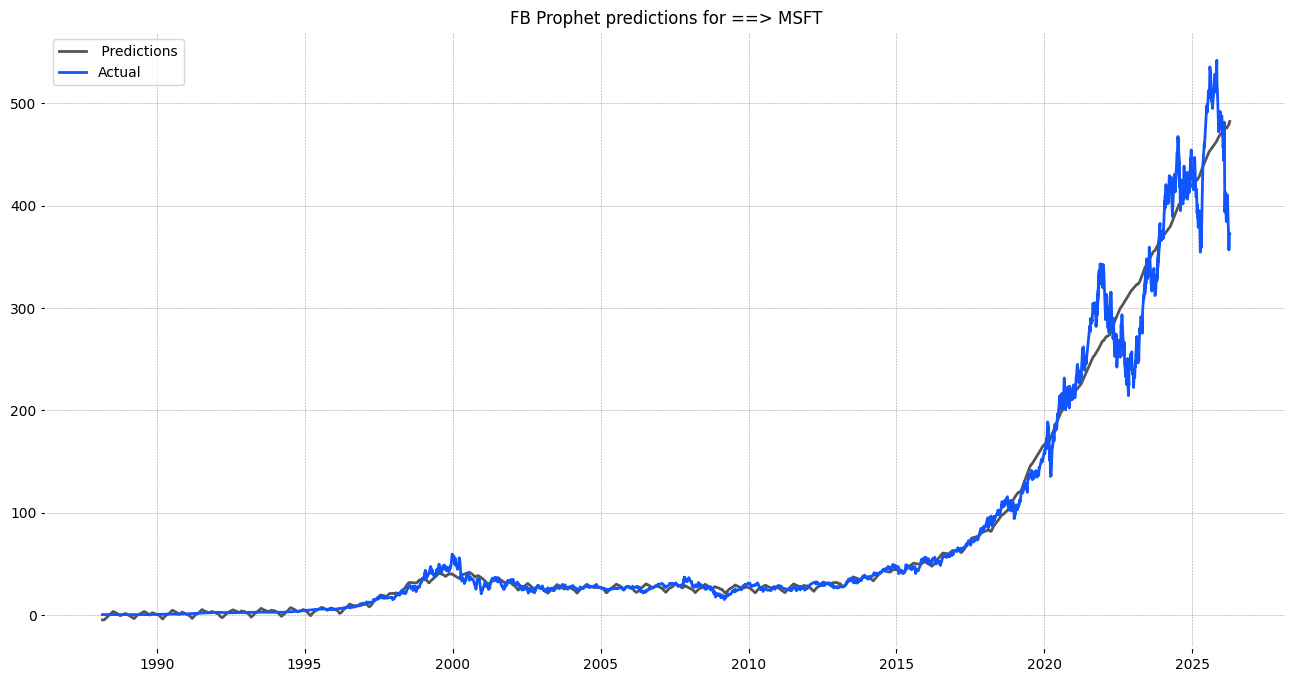

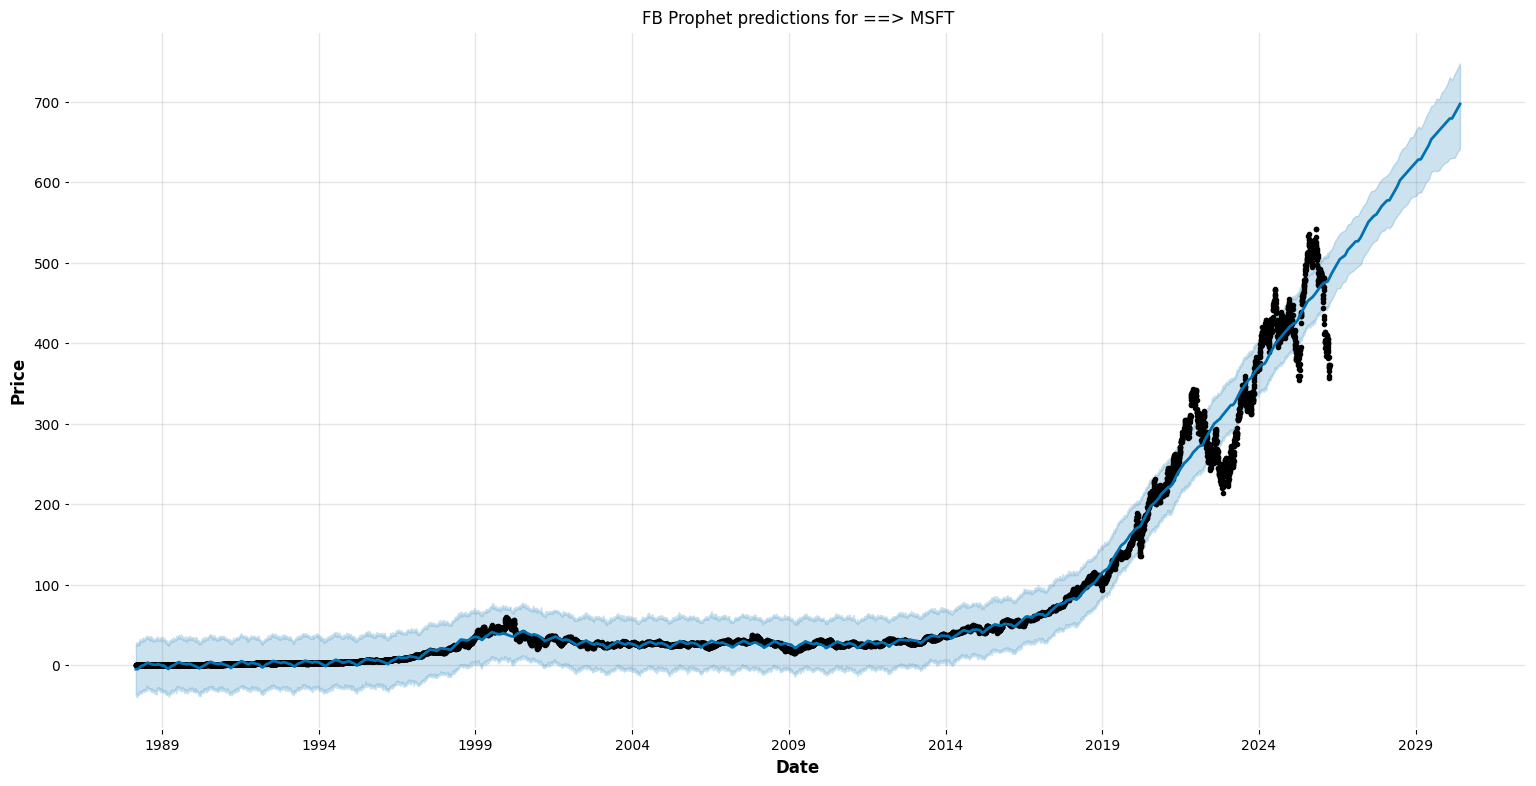

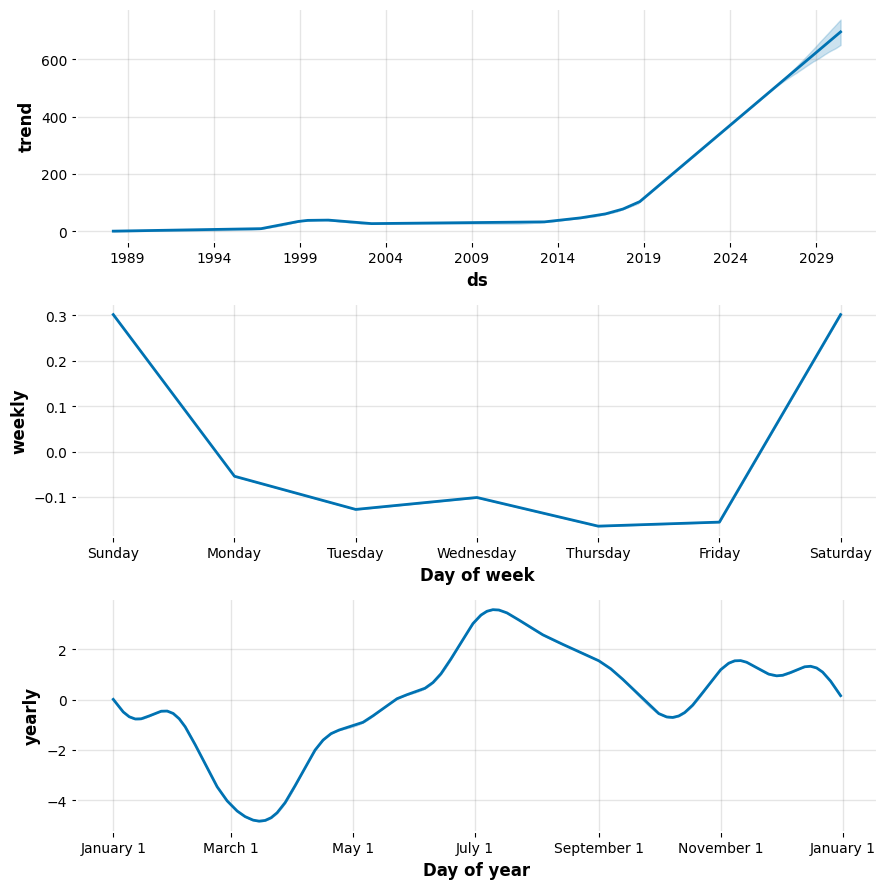

All forecasting done!


In [54]:
plot_close_val(msft, 'Close', 'MSFT') # Plot the Closing Price
fb_prophet_plot(msft, 'Close', 'MSFT')

print("All forecasting done!")

# THIS IS A WORK IN PROGRESS 